# DE1 Homework

In [1]:
import pandas as pd

# Import the TSV file
df = pd.read_csv('id-tourism-sentimentanalysis.tsv', sep='\t')
df.head()

,no,review,sentiment
0,1,bosen singgah pagi siang sore malam ramai keli...,positive
1,2,sedia parkir luas resto tata apik rapi pandang...,positive
2,3,kamar bersih luas staf ramah lokasi guesthouse...,positive
3,4,malang menajubkan lihat kampung warna wrni ni ...,positive
4,5,masjid bersih kota malang letak berangan alun ...,positive


## AWS Translation

In [2]:
from pprint import PrettyPrinter

import boto3

print("📚 Setting up the environment...")
pp = PrettyPrinter(indent=2)
translate = boto3.client("translate")
print("✅ Environment setup complete!")
print(f"🌍 Using AWS region: {translate.meta.region_name}")

📚 Setting up the environment...
✅ Environment setup complete!
🌍 Using AWS region: eu-west-1


In [3]:
# Translate reviews to English
def translate_text(text, source_lang='auto', target_lang='en'):
    """Translate text from source language to target language"""
    response = translate.translate_text(
        Text=text,
        SourceLanguageCode=source_lang,
        TargetLanguageCode=target_lang
    )
    return response['TranslatedText']

# Apply translation to the review column
df['review_english'] = df['review'].apply(translate_text)

# Display first few translated reviews
print("Sample translations:")
for idx in range(min(3, len(df))):
    print(f"\n🇪 Original: {df['review'].iloc[idx]}")
    print(f"🇬🇧 English: {df['review_english'].iloc[idx]}")

Sample translations:

🇪 Original: bosen singgah pagi siang sore malam ramai keliling jalan lingkar bundar ramai kendara jarang alun alun bundar keliling gedung dpr kantor balaikota hotel tugu sekolah favorit destinasi wisata kuliner hehe
🇬🇧 English: Boren stop in the morning noon afternoon at night crowded round ring road crowded roundabout square round square round square around parliament building office balaikota hotel tugu school favorite culinary tourist destination hehe

🇪 Original: sedia parkir luas resto tata apik rapi pandang indah sedia agam menu nusantara es campur segarr angsle porsi relatif cocok potret suasana santai
🇬🇧 English: spacious parking lot resto tidy layout beautiful view ready to go menu archipelago ice mixed fresh angsle portion relatively suitable portrait relaxed atmosphere

🇪 Original: kamar bersih luas staf ramah lokasi guesthouse kota strategis sarap variasi biasa aja harga yg pesan booking com lebih murah tidak sarap lebih langsung booking guesthousenya


## AWS Comprehend

In [4]:
comprehend = boto3.client(service_name="comprehend", region_name="eu-west-1")

In [5]:
# Detect sentiment for each review using Comprehend
def detect_sentiment(text):
    """Detect sentiment from text using AWS Comprehend"""
    response = comprehend.detect_sentiment(Text=text, LanguageCode='en')
    return response['Sentiment']

# Apply sentiment analysis to the English reviews
df['sentiment_comprehend'] = df['review_english'].apply(detect_sentiment)

# Display sample sentiments
print("Sample sentiments:")
for idx in range(min(3, len(df))):
    print(f"\nReview {idx + 1}: {df['review_english'].iloc[idx][:100]}...")
    print(f"Sentiment: {df['sentiment_comprehend'].iloc[idx]}")

Sample sentiments:

Review 1: Boren stop in the morning noon afternoon at night crowded round ring road crowded roundabout square ...
Sentiment: POSITIVE

Review 2: spacious parking lot resto tidy layout beautiful view ready to go menu archipelago ice mixed fresh a...
Sentiment: POSITIVE

Review 3: Clean rooms spacious staff friendly location guesthouse strategic city eat usual variety only cheape...
Sentiment: POSITIVE


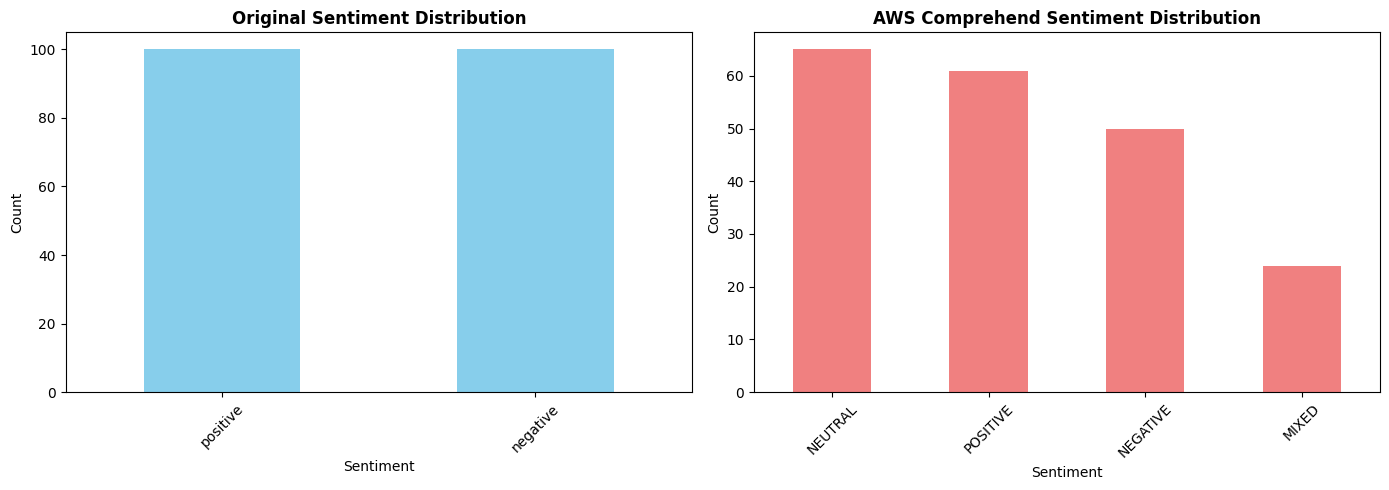


📊 Sentiment Comparison:

Original Sentiment:
sentiment
positive    100
negative    100
Name: count, dtype: int64

Comprehend Sentiment:
sentiment_comprehend
NEUTRAL     65
POSITIVE    61
NEGATIVE    50
MIXED       24
Name: count, dtype: int64


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Original sentiment distribution
df['sentiment'].value_counts().plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Original Sentiment Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Comprehend sentiment distribution
df['sentiment_comprehend'].value_counts().plot(kind='bar', ax=axes[1], color='lightcoral')
axes[1].set_title('AWS Comprehend Sentiment Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print comparison statistics
print("\n📊 Sentiment Comparison:")
print(f"\nOriginal Sentiment:\n{df['sentiment'].value_counts()}")
print(f"\nComprehend Sentiment:\n{df['sentiment_comprehend'].value_counts()}")

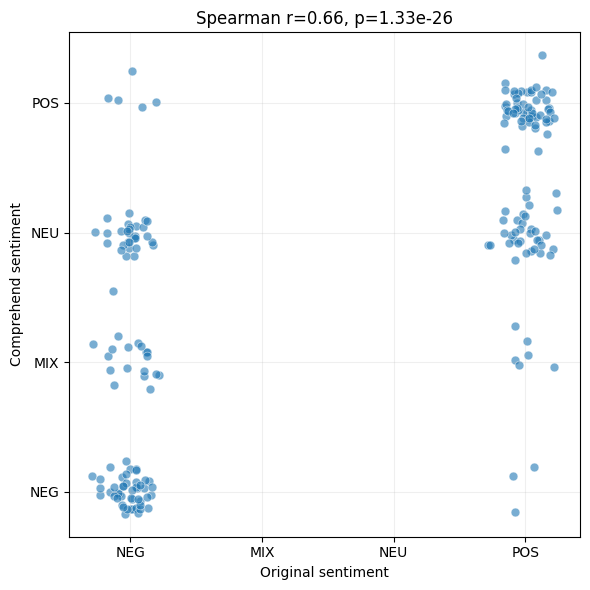

In [7]:
import numpy as np
import seaborn as sns

# Map sentiment labels to numeric scores
mapping = {'NEGATIVE': 1, 'MIXED': 2, 'NEUTRAL': 3, 'POSITIVE': 4}
orig = df['sentiment'].astype(str).str.upper().map(mapping)
comp = df['sentiment_comprehend'].astype(str).str.upper().map(mapping)
plot_df = pd.DataFrame({'orig': orig, 'comp': comp}).dropna()
if plot_df.empty:
    print('No paired sentiment values to plot.')
else:
    # jitter for visibility
    rng = np.random.default_rng(0)
    x = plot_df['orig'] + rng.normal(0, 0.12, size=len(plot_df))
    y = plot_df['comp'] + rng.normal(0, 0.12, size=len(plot_df))

    # Spearman correlation
    try:
        from scipy.stats import spearmanr
        r, p = spearmanr(plot_df['orig'], plot_df['comp'])
    except Exception:
        r = plot_df['orig'].corr(plot_df['comp'], method='spearman')
        p = None

    plt.figure(figsize=(6,6))
    sns.scatterplot(x=x, y=y, alpha=0.6, s=40)
    plt.xlabel('Original sentiment')
    plt.ylabel('Comprehend sentiment')
    title = f'Spearman r={r:.2f}' + (f', p={p:.3g}' if p is not None else '')
    plt.title(title)
    ticks = [1,2,3,4]
    labels = ['NEG','MIX','NEU','POS']
    plt.xticks(ticks, labels)
    plt.yticks(ticks, labels)
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

## AWS Bedrock

In [8]:
bedrock = boto3.client("bedrock-runtime")
MODEL_ID = "eu.amazon.nova-micro-v1:0"

In [13]:
import json
import re
import time
import botocore

def generate_review_score(review_text, retries=3, backoff=1.0):
    """Return an integer 1-5 for a review using Bedrock (customer-perspective prompt)."""
    if not isinstance(review_text, str) or not review_text.strip():
        return 3  # neutral default for empty review

    prompt = (
        f"You are a customer who used this tourism service and wrote the following review in English.\n"
        "Based on your written review, provide a rating from 1 to 5 where:\n"
        "1 = Very dissatisfied\n2 = Dissatisfied\n3 = Neutral\n4 = Satisfied\n5 = Very satisfied\n\n"
        f"Review: \"{review_text}\"\n\nRespond with ONLY a single number (1-5)."
    )

    # IMPORTANT: content must be an ARRAY of content objects, not a plain string
    body = {
        "messages": [
            {
                "role": "user",
                "content": [
                    {"text": prompt}
                ]
            }
        ]
    }

    for attempt in range(1, retries + 1):
        try:
            resp = bedrock.invoke_model(
                modelId=MODEL_ID,
                contentType="application/json",
                accept="application/json",
                body=json.dumps(body)
            )
            resp_body = json.loads(resp["body"].read())

            # Robust extraction of text from response
            def find_text(obj):
                if isinstance(obj, dict):
                    if "text" in obj and isinstance(obj["text"], str):
                        return obj["text"]
                    for v in obj.values():
                        res = find_text(v)
                        if res: return res
                elif isinstance(obj, list):
                    for item in obj:
                        res = find_text(item)
                        if res: return res
                return None

            text = find_text(resp_body) or json.dumps(resp_body)
            m = re.search(r"\b([1-5])\b", text)
            if m:
                return int(m.group(1))
            return 3
        except botocore.exceptions.ClientError as e:
            print(f"Bedrock client error (attempt {attempt}): {e}")
        except Exception as e:
            print(f"Bedrock error (attempt {attempt}): {e}")
        time.sleep(backoff * (2 ** (attempt - 1)))

    return 3  # fallback if all retries fail

# Test a single sample first:
sample = df['review_english'].dropna().iloc[0]
print("Sample call result:", generate_review_score(sample))

Sample call result: 1


In [14]:
df['review_scores'] = df['review_english'].fillna("").apply(generate_review_score)
df.head()

,no,review,sentiment,review_english,sentiment_comprehend,review_scores
0,1,bosen singgah pagi siang sore malam ramai keli...,positive,Boren stop in the morning noon afternoon at ni...,POSITIVE,1
1,2,sedia parkir luas resto tata apik rapi pandang...,positive,spacious parking lot resto tidy layout beautif...,POSITIVE,4
2,3,kamar bersih luas staf ramah lokasi guesthouse...,positive,Clean rooms spacious staff friendly location g...,POSITIVE,4
3,4,malang menajubkan lihat kampung warna wrni ni ...,positive,I'm sorry to see the village colors that are g...,POSITIVE,1
4,5,masjid bersih kota malang letak berangan alun ...,positive,clean mosque malang city center square,NEUTRAL,5


In [19]:
df.describe()

,no,review_scores
count,200.000000,200.00000
mean,100.500000,2.39500
std,57.879185,1.35579
min,1.000000,1.00000
25%,50.750000,1.00000
50%,100.500000,2.00000
75%,150.250000,3.00000
max,200.000000,5.00000


/tmp/ipykernel_3298/1532364795.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sentiment', y='review_scores', data=plot_df, palette='pastel')


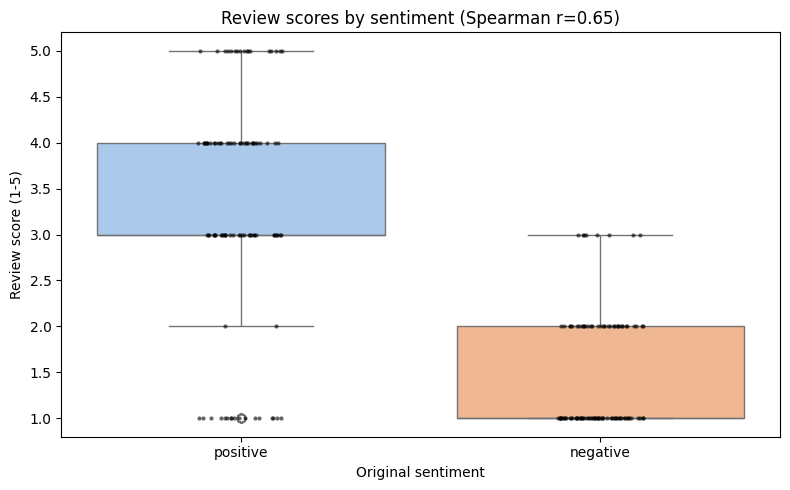

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(x='sentiment', y='review_scores', data=plot_df, palette='pastel')
sns.stripplot(x='sentiment', y='review_scores', data=plot_df, color='k', size=3, alpha=0.6, jitter=0.12)
plt.title(f'Review scores by sentiment (Spearman r={r:.2f})')
plt.ylabel('Review score (1-5)')
plt.xlabel('Original sentiment')
plt.tight_layout()
plt.show()

In [25]:

def generate_chief_complaint(review_text, retries=2, backoff=1.0):
    """Return the primary (chief) complaint phrase for a review using Bedrock.
    If the review contains only praise or no complaint, returns the token 'NO_COMPLAINT'.
    If there's no clear single complaint, returns 'NO_CLEAR_COMPLAINT'."""
    if not isinstance(review_text, str) or not review_text.strip():
        return "NO_COMPLAINT"

    # Clear, constraint-based prompt that asks for a single short phrase or a token
    prompt = (
        "You are a concise text analyst. Read the customer review below and extract the single primary complaint (the chief complaint).\n"
        "Respond with ONLY one short phrase (3-10 words) that best summarizes the main complaint.\n"
        "If the review contains only praise or no complaint, respond with the exact token: NO_COMPLAINT.\n"
        "If there is no clear single complaint (multiple equal issues or ambiguity), respond with the exact token: NO_CLEAR_COMPLAINT.\n\n"
        f"Review: \"{review_text}\"\n\nRespond with ONLY the short complaint phrase or one of: NO_COMPLAINT or NO_CLEAR_COMPLAINT."
    )

    # Use the same working body shape that the rating function uses: messages -> content -> [{"text": ...}]
    # This avoids the ValidationExceptions we observed when content items were strings or had extraneous keys.
    bodies = [
        {"messages": [{"role": "user", "content": [{"text": prompt}]}]},
    ]

    for body in bodies:
        for attempt in range(1, retries + 1):
            try:
                resp = bedrock.invoke_model(
                    modelId=MODEL_ID,
                    contentType="application/json",
                    accept="application/json",
                    body=json.dumps(body)
                )
                resp_body = json.loads(resp["body"].read())

                # Robust extraction: find any string-like response in nested structures
                def find_text(obj):
                    if isinstance(obj, dict):
                        for k, v in obj.items():
                            if isinstance(v, str) and v.strip():
                                return v
                            res = find_text(v)
                            if res:
                                return res
                    elif isinstance(obj, list):
                        for item in obj:
                            res = find_text(item)
                            if res:
                                return res
                    return None

                text = find_text(resp_body) or ""
                text = text.strip().strip('"')

                # Normalize common replies
                upper = text.upper()
                if upper in ("NO_COMPLAINT", "NO COMPLAINT", "NO-complaint".upper()):
                    return "NO_COMPLAINT"
                if upper in ("NO_CLEAR_COMPLAINT", "NO CLEAR COMPLAINT"):
                    return "NO_CLEAR_COMPLAINT"

                # Otherwise, return the concise first line truncated to 60 chars
                if text:
                    first_line = text.splitlines()[0].strip()
                    # enforce shortness (if model returns long text, take concise chunk)
                    if len(first_line.split()) > 12:
                        # try to pick up first clause up to comma/semicolon
                        parts = re.split(r"[,;:\.]", first_line)
                        first_line = parts[0].strip()
                    return first_line

                break
            except botocore.exceptions.ClientError as e:
                err = str(e)
                # Print error and a compact preview of the body so we can see what shape caused the ValidationException
                try:
                    preview = json.dumps(body)[:300]
                except Exception:
                    preview = str(body)
                print(f"Bedrock client error (attempt {attempt}, format trial): {err}")
                print(f"  Body preview: {preview}...")
                if attempt < retries:
                    time.sleep(backoff * (2 ** (attempt - 1)))
                    continue
                else:
                    break
            except Exception as e:
                print(f"Bedrock error (attempt {attempt}): {e}")
                if attempt < retries:
                    time.sleep(backoff * (2 ** (attempt - 1)))
                    continue
                else:
                    break

    # Fallback when no usable response
    return "NO_COMPLAINT"


# Test on the first English review and print the chief complaint nicely
sample = df['review_english'].dropna().iloc[0]
complaint = generate_chief_complaint(sample)
if complaint == "NO_COMPLAINT":
    print("Chief complaint: No complaint (the review is praise or contains no complaint).")
elif complaint == "NO_CLEAR_COMPLAINT":
    print("Chief complaint: No clear single complaint could be identified.")
else:
    print(f"Chief complaint: {complaint}")


Chief complaint: No complaint (the review is praise or contains no complaint).
